# Exploratory Data Analysis with Review Sampled Dataset [with Game Use Cases]
direct link to download data:
https://drive.google.com/uc?id=1tWJSm0wWvduyNjx0Mnk6NBpeFahsZNbI&export=download

In [1]:
# Make sure you are at the parent directory
from pathlib import Path
import sys
import os

# Define MODE
MODE = "LOCAL" # Either "COLAB", "LOCAL", "EXPANSE"
if MODE.upper() not in ('EXPANSE', 'COLAB', 'LOCAL'):
    raise Exception("Invalid mode, the only acceptible are 'EXPANSE', 'COLAB', 'LOCAL'")
if MODE.upper() == "COLAB":
    from google.colab import drive
    drive.mount('/content/drive')

# --- Java 17 for PySpark (LOCAL) ---
# PySpark 4.x requires Java 17/21. On a fresh Mac the default `java` may be older
# (e.g. 15), and VS Code notebook kernels often don't inherit JAVA_HOME from your
# shell -- which causes `JAVA_GATEWAY_EXITED` / UnsupportedClassVersionError when
# create_spark_session() launches the JVM. Point Spark at a JDK 17 here.
if MODE.upper() == "LOCAL" and not os.environ.get("JAVA_HOME"):
    _java_candidates = [
        "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",  # Homebrew (Apple Silicon)
        "/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",     # Homebrew (Intel)
        "/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home",  # Temurin / Adoptium
    ]
    for _jh in _java_candidates:
        if Path(_jh).exists():
            os.environ["JAVA_HOME"] = _jh
            os.environ["PATH"] = _jh + "/bin:" + os.environ["PATH"]
            break
    print("JAVA_HOME:", os.environ.get("JAVA_HOME", "(not set -- install JDK 17: brew install openjdk@17)"))

# Root path by MODE
def find_root(markers=(".git", "requirements.txt", "data")):
    """Walk up from the current dir until we find the repo root."""
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if any((cand / m).exists() for m in markers):
            return cand
    raise FileNotFoundError("Could not locate project root (no .git/requirements.txt/data found)")

PROJECT_ROOT_BY_MODE = {
    "COLAB":   Path("/content/drive/MyDrive/DSC 288R/Project"),
    "EXPANSE": Path("/home/bguo3/bguo3/DSC-288R-Capstone-Final-Project"),
    "LOCAL":   find_root(),
}
ROOT = PROJECT_ROOT_BY_MODE[MODE.upper()]

# Add the root path to global system
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT.resolve()))

# Print the root path
print("MODE:", MODE)
print("PROJECT_ROOT:", ROOT)

JAVA_HOME: /opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home
MODE: LOCAL
PROJECT_ROOT: /Users/steveg/Desktop/DSC-288R-Capstone-Final-Project


## Import Modules

In [2]:
from pyspark.sql import functions as F

import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.paths_utils import ProjectPaths
from src.utils.pyspark_utils import create_spark_session
from src.utils.io_utils import read_spark_parquet

## Read Subsample Cleaned Data Parquet File

In [3]:
# INITIALIZING THE SPARK
spark = create_spark_session(
    "steam_reviews_EDA_review_sampled",
    extra_configs={"spark.driver.memory": "4g", "spark.master": "local[*]"},
)

# Loading up our parquet
# LOAD THE DATA FROM WHEREVER YOU ARE HOLDING IT!
paths = ProjectPaths(MODE)
df = read_spark_parquet(spark, str(paths.sampled_parquet))

# # Check the Spark details
print('master:', spark.sparkContext.master)
print('partitions:', df.rdd.getNumPartitions())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/04 19:47:55 WARN Utils: Your hostname, MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.0.0.2 instead (on interface en0)
26/06/04 19:47:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/04 19:47:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/04 19:47:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Read Spark parquet from: /Users/steveg/Desktop/DSC-288R-Capstone-Final-Project/data/subsampled_parquet
master: local[*]
partitions: 33


In [4]:
# # How much data do we have here?
# # Total number of reviews in the subsample
df.count()

2105211

# Let's really quickly go over the columns and what purpose they serve:

## Column Overview Table
| Column Name                      | Type      | Description                                                                                          |
| -------------------------------- | --------- | ---------------------------------------------------------------------------------------------------- |
| `author_steamid`                 | Long      | Unique Steam user ID for the reviewer.                                                               |
| `appid`                          | Long      | Unique Steam application/game ID identifying the reviewed game.                                      |
| `author_num_games_owned`         | Integer   | Number of games owned by the reviewer on Steam. Proxy for platform engagement.                       |
| `author_num_reviews`             | Integer   | Total number of reviews written by the user. Proxy for reviewer activity.                            |
| `author_playtime_forever`        | Integer   | Total lifetime playtime for the game (minutes).                                                      |
| `author_playtime_last_two_weeks` | Integer   | Minutes played in the last 14 days. Strong indicator of recent engagement/retention.                 |
| `author_playtime_at_review`      | Integer   | Total playtime (minutes) when the review was originally submitted. Useful for early vs late reviews. |
| `author_last_played`             | Timestamp | Most recent recorded time the reviewer played the game.                                              |
| `review`                         | String    | Raw written text of the user review. Primary NLP feature source.                                     |
| `voted_up`                       | Boolean   | Whether the review is recommended (positive=True, negative=False). Common target variable.           |
| `votes_up`                       | Integer   | Number of users who marked the review helpful.                                                       |
| `votes_funny`                    | Long      | Number of users who marked the review funny.                                                         |
| `weighted_vote_score`            | Float     | Steam confidence/helpfulness score, likely adjusted for quality/trust.                               |
| `comment_count`                  | Integer   | Number of comments/replies on the review.                                                            |
| `written_during_early_access`    | Boolean   | Whether the review was written while the game was in Early Access.                                   |
| `language`                       | String    | Language the review was written in.                                                                  |
| `timestamp_created`              | Timestamp | Time the review was originally created.                                                              |
| `timestamp_updated`              | Timestamp | Most recent time the review was edited or updated.                                                   |

This dataset is a subsample of Steam game reviews and reviewer metadata. It combines textual review content, user platform behavior, engagement metrics, and timestamps. The data supports sentiment analysis, player retention modeling, reviewer behavior analysis, and market intelligence tasks.

## Feature Groups
| Category                    | Features                                                                                                       | Description                                                                                                                               |
| --------------------------- | -------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| Reviewer Identity           | `author_steamid`, `appid`                                                                                      | Unique identifiers for the reviewer and the reviewed game. Used for joins, grouping, and user-game level analysis.                        |
| Reviewer Profile            | `author_num_games_owned`, `author_num_reviews`                                                                 | Measures the reviewer’s overall Steam activity and experience on the platform. Useful for identifying casual vs veteran users.            |
| Gameplay / Retention        | `author_playtime_forever`, `author_playtime_last_two_weeks`, `author_playtime_at_review`, `author_last_played` | Captures historical and recent engagement with the game. Important for churn, retention, and satisfaction analysis.                       |
| Review Target / Sentiment   | `voted_up`                                                                                                     | Binary recommendation outcome indicating whether the user recommends the game. Strong candidate target variable for classification tasks. |
| Review Popularity / Quality | `votes_up`, `votes_funny`, `weighted_vote_score`, `comment_count`                                              | Community reaction metrics that reflect helpfulness, visibility, humor, and engagement with the review.                                   |
| Text Features               | `review`, `language`                                                                                           | Raw review text and language metadata used for NLP, sentiment modeling, topic extraction, and multilingual analysis.                      |
| Lifecycle / Release Context | `written_during_early_access`                                                                                  | Indicates whether the review was written during Early Access, useful for studying unfinished product perceptions.                         |
| Temporal Features           | `timestamp_created`, `timestamp_updated`                                                                       | Review creation and modification timestamps used for time trends, update behavior, and seasonal analysis.                                 |


In [5]:
# Here is a fun peak at the mess we're going to clean up... again...
# If you're coming from the games EDA well nothing much changed other than pushing through!
df.head()

Row(author_steamid=76561198353194077, appid=421050, author_num_games_owned=864, author_num_reviews=252, author_playtime_forever=571, author_playtime_last_two_weeks=0, author_playtime_at_review=571, author_last_played=1515414539, review='字幕里文字颜色不同，开始我还以为是什么关键词。 这作主要讲时空转换，换来换去，开始的第一个地图，要反复攻略3次才算过，挺心累。 感觉这公司的游戏，基本不看攻略都挺难的，做的有点太无厘头，没有什么逻辑可言。 4部都玩了，我还是更喜欢托妮这个前女友一些，不过也只有歌尔这种傻白甜才是渣男贱男的标配啊。', voted_up=True, votes_up=0, votes_funny=0, weighted_vote_score=0.0, comment_count=0, written_during_early_access=False, language='schinese', timestamp_created=1515415190, timestamp_updated=1515415190)

# So Why Are We Using This Data?

Recall that the broader objective of this project is to understand player retention, engagement behavior, and the competitive dynamics of digital games. While the games metadata dataset helps explain characteristics of the products themselves, this review dataset introduces the human side of the ecosystem: how players behave, how they evaluate games, and what signals may indicate continued engagement or disengagement.

Put simply, if the games dataset tells us what a game is, the reviews dataset helps explain how players respond to it.

This distinction is important because retention is rarely determined by genre or tags alone. A game may look attractive on paper, yet fail to sustain its audience due to poor user experience, balance issues, technical problems, or unmet expectations. Reviews provide direct behavioral and sentiment-based evidence of those outcomes.

By analyzing review text, recommendation scores, playtime metrics, helpfulness votes, and timestamps, we can identify patterns such as:

Which types of players leave positive vs negative feedback
Whether higher playtime is associated with stronger satisfaction
Signals of churn, inactivity, or declining engagement
How Early Access status influences player perception
Whether community reception aligns with long-term retention

In this sense, reviews function as a real-world feedback mechanism between developers and players. They capture not only opinions, but also measurable engagement behavior tied to those opinions.

Ultimately, this dataset allows us to move beyond product descriptions and toward player-centered analytics. If the end goal is to understand why games keep or lose their audience, then user reviews are one of the most valuable sources available.

## Primary Feature(s)

### review
The review text column is the richest unstructured feature in the dataset. While voted_up tells us the final outcome, the review text helps explain why the player felt that way.

Through text analysis, this field can reveal recurring themes such as:

bugs or technical issues
balance complaints
praise for gameplay loops
monetization concerns
community toxicity
value for price
replayability

This makes review highly valuable for sentiment modeling, topic modeling, keyword extraction, and explaining patterns found in structured variables.

### author_playtime_forever
This feature measures the reviewer’s total lifetime playtime in minutes for the game. It is one of the strongest behavioral indicators in the dataset because time invested often reflects real engagement.

A negative review after 500 hours may imply burnout, frustration, or changing standards. A positive review after 5 hours may indicate strong first impressions but limited long-term evidence. Because of this, playtime adds important context to review outcomes.

### author_playtime_last_two_weeks
This field captures recent activity and is especially useful for retention analysis. A player with large historical playtime but zero recent activity may have churned, while recent playtime suggests continued engagement.

Among all available features, this is one of the closest proxies for active retention behavior.

## Supporting Feature(s)

### author_num_games_owned
This measures how invested a user is in the Steam ecosystem overall. Users with hundreds of owned games may evaluate titles differently than casual users with smaller libraries.

It can help distinguish between veteran platform users and newer consumers.

### author_num_reviews
This field indicates reviewer activity level. Frequent reviewers may be more analytical, more critical, or more engaged with community discourse than users who rarely leave feedback.

Useful for segmenting reviewer types.

### voted_up
The voted_up field serves as the core outcome variable in this dataset, indicating whether a user recommends the game (True) or does not recommend it (False). This variable provides a direct and interpretable measure of player satisfaction, making it one of the most valuable signals for supervised modeling tasks such as sentiment classification or recommendation outcome prediction.

Unlike raw review text, voted_up is already structured and standardized. It allows us to compare behavior across users, games, and time periods without requiring immediate NLP preprocessing. In many ways, it functions as the clearest summary of whether the user experience met expectations.

This feature is central to project objectives because player approval is often linked to retention, continued playtime, and positive community momentum.

### votes_up, votes_funny, weighted_vote_score
These variables reflect how the broader community responds to a review itself.

They may indicate:

credibility of the review
entertainment value
usefulness to other consumers
visibility/popularity within Steam’s ecosystem

These features are less about the game directly and more about social validation.

### written_during_early_access
This feature adds lifecycle context. Reviews written during Early Access may reflect unfinished systems, missing content, or optimism about future development.

It is useful when comparing perception across release stages.

### language
The language field identifies the written language of each review and supports segmentation of global audiences, localization analysis, and multilingual sentiment research. Regional communities may evaluate games differently due to translation quality, pricing differences, server experience, or cultural preferences.

Analysis is restricted to English-language reviews in order to reduce linguistic noise and improve consistency for text mining, sentiment scoring, and interpretation.

### timestamp_created, timestamp_updated, author_last_played
These temporal fields allow us to study:

review trends over time
post-launch reception changes
user re-engagement cycles
whether users revise opinions later

Time-aware analysis is often critical in live-service or evolving games.

In [6]:
# Our data has been heavily pre-processed and cleaned so we'll dive straight into our data and chart work.
# for now here are a few helper functions to read a game reviews from a particular user and also
# check the user's reviews in historical order or alphabetical by game
def get_review(df, appid, steamid):
    return (
        df.filter(
            (F.col('appid') == appid) &
            (F.col('author_steamid') == steamid)
        )
        .select(
            'appid',
            'author_steamid',
            'voted_up',
            'author_playtime_forever',
            'author_playtime_last_two_weeks',
            'timestamp_created',
            'review'
        )
    )

def user_review_history(df, steamid):
    return (
        df.filter(F.col('author_steamid') == steamid)
        .select(
            'game',
            'appid',
            'voted_up',
            'author_playtime_forever',
            'timestamp_created'
        )
        .orderBy('timestamp_created')
    )

def user_reviews_alpha(df, steamid):
    return (
        df.filter(F.col('author_steamid') == steamid)
        .select(
            'game',
            'appid',
            'voted_up',
            'timestamp_created'
        )
        .orderBy('game')
    )

# all the reviews for a single game
def game_reviews(df, appid, limit_rows=20):
    return (
        df.filter(F.col('appid') == appid)
        .select(
            'author_steamid',
            'voted_up',
            'author_playtime_forever',
            'timestamp_created',
            'review'
        )
        .orderBy(F.desc('timestamp_created'))
        .limit(limit_rows)
    )

# Example Use Case for Viewing Games and Reviews

This review dataset does not directly contain game titles, only Steam application identifiers (appid). However, prior work from the games metadata EDA allows us to map known app IDs to real titles.

For example, Steam appid = 730 corresponds to Counter-Strike 2. Because this title is present in the review subsample, it serves as a useful reference point for exploratory analysis.

Counter-Strike 2 is especially valuable as an example because it has:

a large and active player base
competitive gameplay dynamics
frequent balance and performance discussions
highly engaged long-term users
strong positive and negative review behavior

This makes it an ideal candidate for demonstrating how user reviews, playtime, and sentiment interact within the dataset.

In [7]:
# sanity checking Counter Strike 2 for example purposes
# Check whether Dota 2 exists in the parquet using appid
# DEV NOTE: this is some prior knowledge of the Games EDA
# We would have had to join data using the appid for this to work/
# know the name
df.filter(F.col('appid') == 730) \
  .select('appid') \
  .distinct() \
  .show(truncate=False)

+-----+
|appid|
+-----+
|730  |
+-----+



In [8]:
df.filter(F.col('appid') == 730).count()

145729

## Why Focus on Counter-Strike 2?

While the broader dataset contains reviews across many games, Counter-Strike 2 serves as a particularly valuable case study due to the emotional intensity of its player community.

As a highly competitive multiplayer title, player experiences are shaped not only by gameplay quality, but also by teammates, opponents, ranking systems, cheating concerns, performance issues, and frequent updates. These pressures often produce reviews that are more expressive, polarized, sarcastic, or passive aggressive than those found in many casual titles.

This makes Counter-Strike 2 especially useful for studying nuanced sentiment behavior. A review may be technically positive while containing criticism, or strongly negative despite hundreds of hours of continued play. Such contradictions are common in competitive gaming communities and provide rich signals for behavioral analysis.

In other words, CS2 reviews do not simply measure satisfaction—they often reflect frustration, loyalty, identity, burnout, and long-term attachment.

In [9]:
# Restrict Counter-Strike 2 subset to English-language reviews only
df_cs2 = (
    df.filter(
        (F.col('appid') == 730) &
        (F.lower(F.col('language')) == 'english')
    )
    .cache()
)

df_cs2.count()

40242

In [10]:
df_cs2.head()

Row(author_steamid=76561198140326278, appid=730, author_num_games_owned=0, author_num_reviews=1, author_playtime_forever=15035, author_playtime_last_two_weeks=0, author_playtime_at_review=4754, author_last_played=1419534282, review='10 / 10', voted_up=True, votes_up=0, votes_funny=0, weighted_vote_score=0.0, comment_count=0, written_during_early_access=False, language='english', timestamp_created=1416956850, timestamp_updated=1416956850)

In [11]:
numeric_cols = [
    'author_num_games_owned',
    'author_num_reviews',
    'author_playtime_forever',
    'author_playtime_last_two_weeks',
    'author_playtime_at_review',
    'votes_up',
    'votes_funny',
    'weighted_vote_score',
    'comment_count'
]

(
    df_cs2.select(numeric_cols)
        .summary()
        .show(truncate=False)
)

26/06/04 19:48:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+----------------------+------------------+-----------------------+------------------------------+-------------------------+------------------+--------------------+-------------------+-------------------+
|summary|author_num_games_owned|author_num_reviews|author_playtime_forever|author_playtime_last_two_weeks|author_playtime_at_review|votes_up          |votes_funny         |weighted_vote_score|comment_count      |
+-------+----------------------+------------------+-----------------------+------------------------------+-------------------------+------------------+--------------------+-------------------+-------------------+
|count  |40242                 |40242             |40242                  |40242                         |40242                    |40242             |40242               |40242              |40242              |
|mean   |42.91267829630734     |5.100268376323244 |65034.91342378609      |253.42684260225636            |29703.62974007256        |0.63336812285671

## Key Numerical Observations: Counter-Strike 2 (English Reviews)

After filtering to English-language Counter-Strike 2 reviews, the working dataset contains **40,236 reviews**. Even after narrowing scope, this remains a substantial corpus for behavioral and sentiment analysis.

#### Reviewer Experience is Highly Uneven

The median reviewer owns only **1 game** and has written **2 reviews**, while averages rise to **42.9 games owned** and **5.1 reviews written**.

This indicates a **right-skewed reviewer population**, where a smaller number of highly active Steam users pull averages upward.

---

#### Playtime is Extremely Right-Skewed

Median lifetime playtime is **38,856 minutes** (**647 hours**), while the mean exceeds **65,000 minutes** (**1,083 hours**).

Some players exceed **2 million minutes** of recorded playtime.

This reflects a long tail of **deeply invested veteran players**.

---

#### Recent Activity Varies Widely

The median playtime in the last two weeks is **0 minutes**, meaning at least half of reviewers were not recently active.

However, some users exceed **20,000 recent minutes**, indicating periods of extreme engagement.

This suggests a mixture of **active players, dormant veterans, and churned users**.

---

#### Review Visibility is Sparse for Most Users

Median values for both `votes_up` and `votes_funny` are **0**, meaning most reviews receive little community interaction.

Yet a small minority reach **3,445 helpful votes** and **6,438 funny votes**, showing highly concentrated attention.

---

#### Comment Activity is Minimal

Median `comment_count` is **0**, indicating most reviews are one-way opinions rather than discussions.

---

#### Weighted Vote Scores Suggest Polarization

Median weighted score is **0**, while the 75th percentile reaches roughly **0.50**, meaning only a subset of reviews gain measurable trust or visibility.

## Why This Matters

These patterns suggest Counter-Strike 2 reviews are driven by:

- **long-term veteran players**
- **unequal engagement levels**
- **inactive vs active user tension**
- **viral review concentration**
- **emotionally invested communities**

## Note on Sampling Bias

This dataset represents a **subsample** of the broader Steam reviews population rather than the complete universe of Counter-Strike 2 reviews. As a result, observed statistics should be interpreted as descriptive of the sampled data rather than definitive estimates of the full player base.

Sampling may overrepresent or underrepresent certain user groups such as highly active players, recent reviewers, English-speaking users, or individuals more likely to leave feedback. Likewise, sentiment ratios, playtime averages, and engagement metrics may differ from the complete review ecosystem.

For this reason, findings in this notebook are best viewed as **directional insights** and exploratory patterns rather than final population-level conclusions.

In [12]:
# Remove Counter-Strike 2 dataframe from cache
df_cs2.unpersist()

DataFrame[author_steamid: bigint, appid: int, author_num_games_owned: int, author_num_reviews: int, author_playtime_forever: int, author_playtime_last_two_weeks: int, author_playtime_at_review: int, author_last_played: bigint, review: string, voted_up: boolean, votes_up: int, votes_funny: bigint, weighted_vote_score: float, comment_count: int, written_during_early_access: boolean, language: string, timestamp_created: bigint, timestamp_updated: bigint]

# ON TO THE NEXT GAME! Elden Ring

In [13]:
# Recall we found this using the game data
df.filter(F.col('appid') == 1245620) \
    .select('appid') \
    .distinct() \
    .show(truncate=False)

df.filter(F.col('appid') == 1245620).count()

# Restrict Elden Ring subset to English-language reviews only
df_elden = (
    df.filter(
        (F.col('appid') == 1245620) &
        (F.lower(F.col('language')) == 'english')
    )
    .cache()
)

df_elden.count()

+-------+
|appid  |
+-------+
|1245620|
+-------+



7170

## Case Study Shift: Elden Ring

After exploring Counter-Strike 2 as a competitive multiplayer ecosystem, the analysis now shifts to Elden Ring as a contrasting single-player action RPG environment.

Where CS2 reviews may be shaped by teammates, ranked frustration, cheating concerns, and performance issues, Elden Ring reviews are more likely influenced by challenge, progression, world exploration, boss encounters, and personal accomplishment.

This allows the notebook to compare how fundamentally different game structures produce different forms of player sentiment and engagement behavior.

In [14]:
df_elden.select(numeric_cols).summary().show(truncate=False)

+-------+----------------------+------------------+-----------------------+------------------------------+-------------------------+------------------+-----------------+-------------------+-------------------+
|summary|author_num_games_owned|author_num_reviews|author_playtime_forever|author_playtime_last_two_weeks|author_playtime_at_review|votes_up          |votes_funny      |weighted_vote_score|comment_count      |
+-------+----------------------+------------------+-----------------------+------------------------------+-------------------------+------------------+-----------------+-------------------+-------------------+
|count  |7170                  |7170              |7170                   |7170                          |7170                     |7170              |7170             |7170               |7170               |
|mean   |91.91827057182705     |11.552440725244072|11215.641283124129     |40.17866108786611             |4700.27350069735         |0.7735006973500698|0.3987447

## Key Numerical Observations: Elden Ring (English Reviews)

After filtering to English-language Elden Ring reviews, the working dataset contains **7,170 reviews**. While smaller than the Counter-Strike 2 subset, this remains a strong sample size for exploratory analysis and provides a contrasting player ecosystem centered around single-player progression and challenge.


### Reviewer Profiles Suggest Broader Steam Engagement

The median reviewer owns **0 games** in the sampled metadata field and has written **5 reviews**, while average values rise to **91.9 games owned** and **11.6 reviews written**.

This indicates a right-skewed reviewer population where some highly active Steam users substantially raise the mean. Compared with Counter-Strike 2, Elden Ring reviewers appear to come from a more broadly engaged gaming audience.

---

### Playtime Remains Right-Skewed, but Lower than CS2

Median lifetime playtime is **8,801 minutes** (~**147 hours**), while the mean exceeds **11,200 minutes** (~**187 hours**).

Some players exceed **171,000 minutes** of recorded playtime, though overall engagement levels are notably lower than the Counter-Strike 2 case study. This is consistent with a premium single-player title where users may complete the experience rather than remain indefinitely active.

---

### Recent Activity is Often Minimal

The median playtime in the last two weeks is **0 minutes**, indicating that at least half of reviewers were not recently active at the time of data capture.

This pattern may reflect natural completion cycles, intermittent return play, or users who reviewed the game after finishing major content.

---

### Review Visibility is Concentrated

Median values for both `votes_up` and `votes_funny` are **0**, meaning most reviews receive limited community attention.

However, maximum values reach **1,826 helpful votes** and **1,847 funny votes**, suggesting that a smaller number of memorable or highly visible reviews attract outsized engagement.

---

### Comment Activity is Very Low

Median `comment_count` is **0**, and overall averages remain small. As with many Steam reviews, most entries function more as individual opinions than active discussion threads.

---

### Weighted Scores Suggest Selective Trust Signals

Median weighted score is **0**, while upper quartiles begin to rise modestly. This implies that only a subset of reviews accumulate enough visibility or perceived usefulness to receive stronger weighting signals.

## Why This Matters

These numerical patterns suggest Elden Ring reviews are shaped by:

- **completion-oriented player behavior**
- **high but finite engagement cycles**
- **reviewers with broader gaming experience**
- **less persistent activity than live-service titles**
- **strong opinions concentrated into fewer standout reviews**

This creates a meaningful contrast with Counter-Strike 2, where reviews were more closely tied to ongoing competition, repeated play, and long-term multiplayer investment.

In [15]:
# Remove Counter-Strike 2 dataframe from cache
df_elden.unpersist()

DataFrame[author_steamid: bigint, appid: int, author_num_games_owned: int, author_num_reviews: int, author_playtime_forever: int, author_playtime_last_two_weeks: int, author_playtime_at_review: int, author_last_played: bigint, review: string, voted_up: boolean, votes_up: int, votes_funny: bigint, weighted_vote_score: float, comment_count: int, written_during_early_access: boolean, language: string, timestamp_created: bigint, timestamp_updated: bigint]

# Univariate Graphical Exploratory Data Analysis for Both Games!

In [16]:
sentiment_df = (
    df.filter(
        ((F.col('appid') == 730) | (F.col('appid') == 1245620)) &
        (F.lower(F.col('language')) == 'english')
    )
    .withColumn(
        'game',
        F.when(F.col('appid') == 730, 'CS2')
         .otherwise('Elden Ring')
    )
    .groupBy('game', 'voted_up')
    .count()
    .toPandas()
)

,game,voted_up,count,total,percent
0,CS2,True,35931,40242,89.287312
1,CS2,False,4311,40242,10.712688
2,Elden Ring,False,428,7170,5.969317
3,Elden Ring,True,6742,7170,94.030683


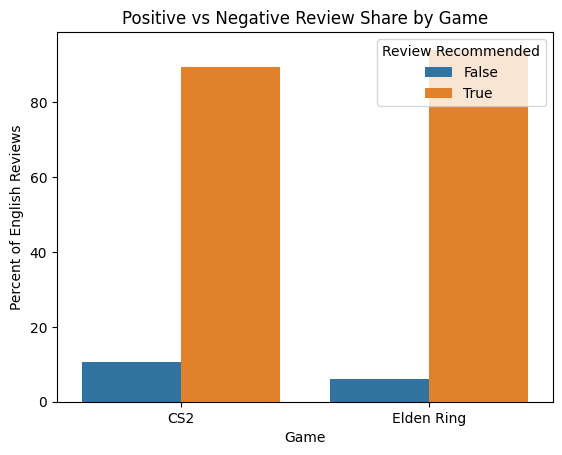

In [17]:
sentiment_pct = (
    sentiment_df
    .assign(total=lambda x: x.groupby('game')['count'].transform('sum'))
    .assign(percent=lambda x: x['count'] / x['total'] * 100)
)

display(sentiment_pct)

sns.barplot(
    data=sentiment_pct,
    x='game',
    y='percent',
    hue='voted_up'
)

plt.title('Positive vs Negative Review Share by Game')
plt.xlabel('Game')
plt.ylabel('Percent of English Reviews')
plt.legend(title='Review Recommended')
plt.show()

**Interpretation**

Both Counter-Strike 2 and Elden Ring have majority-positive English review samples, but Elden Ring shows a stronger positive review share. This suggests that the sampled Elden Ring review environment is more consistently favorable, while CS2 contains a larger visible negative-review segment.

This distinction supports the broader case-study comparison: CS2 reflects a competitive live-service ecosystem where frustration, repeated play, and community tension may shape review behavior, while Elden Ring reflects a more completion-oriented single-player experience with stronger overall approval.

---
---

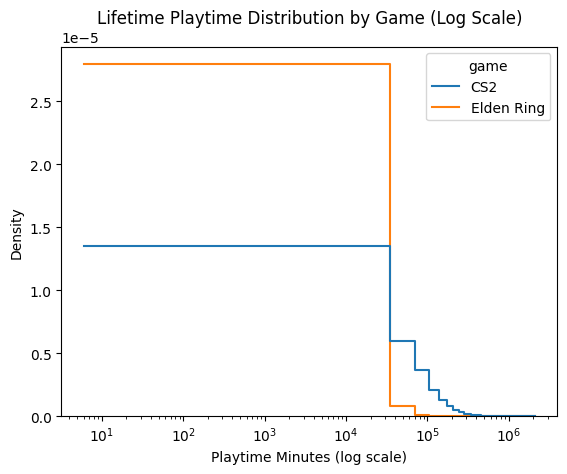

In [18]:
playtime_df = (
    df.filter(
        ((F.col('appid') == 730) | (F.col('appid') == 1245620)) &
        (F.lower(F.col('language')) == 'english')
    )
    .withColumn(
        'game',
        F.when(F.col('appid') == 730, 'CS2')
         .otherwise('Elden Ring')
    )
    .select('game', 'author_playtime_forever')
    .toPandas()
)

sns.histplot(
    data=playtime_df,
    x='author_playtime_forever',
    hue='game',
    bins=60,
    stat='density',
    common_norm=False,
    element='step',
    fill=False
)

plt.xscale('log')
plt.title('Lifetime Playtime Distribution by Game (Log Scale)')
plt.xlabel('Playtime Minutes (log scale)')
plt.ylabel('Density')
plt.show()

**Interpretation**

The lifetime playtime distribution highlights a meaningful difference in long-term engagement patterns between the two games. Counter-Strike 2 exhibits a heavier upper tail, with more users reaching extremely high playtime totals. This is consistent with a competitive live-service title designed around repeated matches, ranking progression, and sustained multiplayer retention.

Elden Ring also shows substantial player investment, but the distribution tapers earlier and with fewer extreme outliers. This aligns more closely with a premium single-player experience where many users invest heavily for a period of time, then eventually complete or pause the game rather than continue indefinitely.

In practical terms, the graph suggests that Counter-Strike 2 is more associated with ongoing habitual engagement, while Elden Ring is more associated with intensive but finite engagement cycles.

---
---

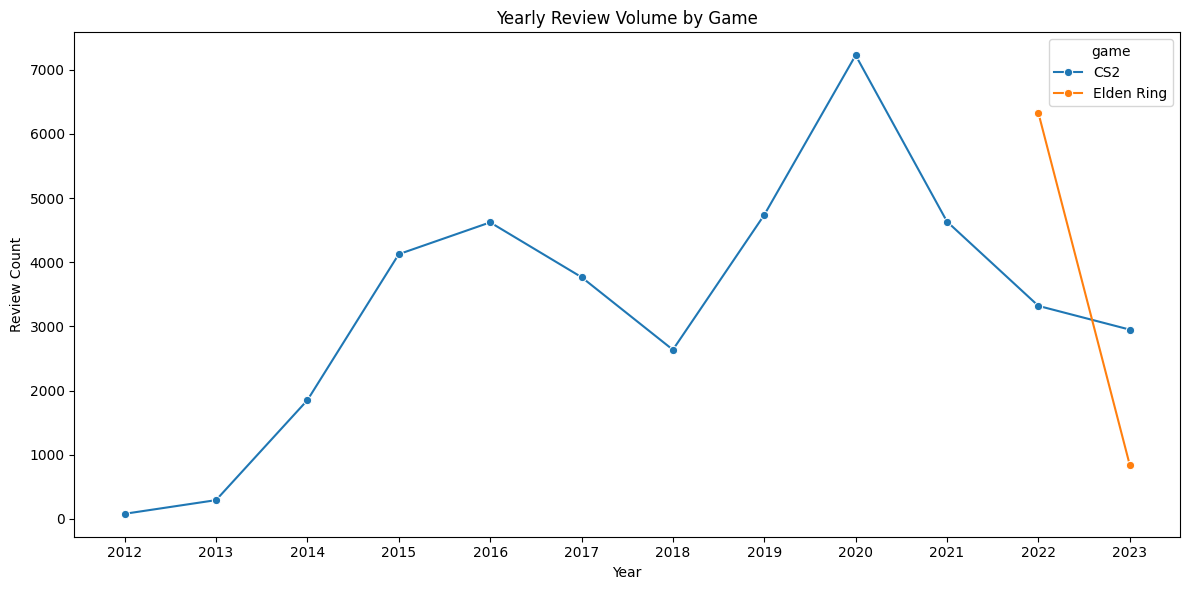

In [19]:
# Build yearly review counts for cleaner lifecycle trends
yearly_df = (
    df.filter(
        ((F.col('appid') == 730) | (F.col('appid') == 1245620)) &
        (F.lower(F.col('language')) == 'english')
    )
    .withColumn(
        'game',
        F.when(F.col('appid') == 730, 'CS2')
         .otherwise('Elden Ring')
    )
    .withColumn('year', F.year(F.from_unixtime(F.col('timestamp_created'))))
    .groupBy('game', 'year')
    .count()
    .orderBy('year')
    .toPandas()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_df,
    x='year',
    y='count',
    hue='game',
    marker='o'
)

plt.title('Yearly Review Volume by Game')
plt.xlabel('Year')
plt.ylabel('Review Count')
plt.xticks(sorted(yearly_df['year'].unique()))
plt.tight_layout()
plt.show()

**Interpretation**

The yearly review timeline illustrates how player attention evolves differently across the two game ecosystems. Counter-Strike 2 shows sustained review activity across many years, with multiple periods of renewed momentum rather than a single isolated peak. This pattern is consistent with a long-running competitive multiplayer title that continues generating discussion through updates, technical changes, esports visibility, and recurring player re-engagement.

Elden Ring displays a more concentrated review surge around its release-era window, followed by a notable decline in later years. This is more typical of premium single-player titles, where player interest often peaks near launch, major content releases, and award-cycle visibility before tapering over time.

In practical terms, the chart reinforces the distinction between **persistent live-service engagement** (CS2) and **front-loaded release engagement** (Elden Ring).